In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sbs
import math as math
import os
from os import listdir
pd.options.mode.use_inf_as_na = True
import tkinter
from tkinter import filedialog
import scipy as scp

In [2]:
import os
import pandas as pd

def data_to_dataframe(pathinfo, y_col='Y (cm)', x_col='X (cm)', speed_col='SPEED#wcentroid (cm/s)', vy_col='VY (cm/s)', frame_col='frame'):
    """
    Reads CSV files from a specified directory tree, extracts specific columns, and compiles them into a single pandas DataFrame.

    This function traverses the directory tree starting at `pathinfo`, identifies CSV files with "Trial" in their filenames,
    and extracts specific columns. It combines these extracted columns into a single DataFrame with additional metadata 
    about the trial and condition.

    Parameters:
    -----------
    pathinfo : str
        The root directory from which to start searching for CSV files.
    y_col : str, optional
        Column name for Y coordinates, default is 'Y (cm)'.
    x_col : str, optional
        Column name for X coordinates, default is 'X (cm)'.
    speed_col : str, optional
        Column name for speed, default is 'SPEED#wcentroid (cm/s)'.
    vy_col : str, optional
        Column name for Y velocity, default is 'VY (cm/s)'.
    frame_col : str, optional
        Column name for frame, default is 'frame'.

    Returns:
    --------
    pandas.DataFrame
        A DataFrame containing concatenated data from all relevant CSV files, with columns for Y, X, Speed, VY, Frame, Trial, and Condition.

    Notes:
    ------
    - The function assumes that the CSV files contain the specified columns.
    - The 'Trial' and 'Condition' columns are derived from the directory structure where the CSV files are found.
    - Uses os.path.join for cross-platform compatibility.

    Example:
    --------
    >>> df = data_to_dataframe("C:\\data\\experiments")
    >>> print(df.head())
    """
    
    df_files = []
    i = 0

    for root, dirs, files in os.walk(pathinfo):
        for f in files:
            if f.endswith(".csv") and "Trial" in f:
                file_path = os.path.join(root, f)
                try:
                    a = pd.read_csv(file_path)
                    data = {
                        "Y": a[y_col],
                        "X": a[x_col],
                        "Speed": a[speed_col],
                        "VY": a[vy_col],
                        "Frame": a[frame_col],
                        "Trial": os.path.basename(root),
                        "Condition": os.path.basename(os.path.dirname(root))
                    }
                    df_files.append(pd.DataFrame(data))
                    i += 1
                except KeyError as e:
                    print(f"Missing column in file {file_path}: {e}")
                except Exception as e:
                    print(f"Error processing file {file_path}: {e}")

    if df_files:
        complete_df = pd.concat(df_files, ignore_index=True)
    else:
        complete_df = pd.DataFrame()

    return complete_df

def clean_dataframe(df):
    """
    Cleans the DataFrame by dropping rows with missing values and filtering 
    rows based on the 'Speed' column.

    This function removes rows with any missing values and retains only rows 
    where the 'Speed' value is between 0.5 and 2.0 (exclusive).

    Parameters:
    -----------
    df : pandas.DataFrame
        The DataFrame to be cleaned.

    Returns:
    --------
    pandas.DataFrame
        The cleaned DataFrame with no missing values and 'Speed' values 
        between 0.5 and 2.0.
    
    Example:
    --------
    >>> df = data_to_dataframe("C:\\data\\experiments")
    >>> clean_df = clean_dataframe(df)
    >>> print(clean_df.head())
    """

    df_cleaned = df.dropna()
    df_cleaned = df_cleaned[df_cleaned["Speed"].between(0.5, 2.0, inclusive='neither')]
    return df_cleaned

def calculate_distance_from_fixed_point(df):
    """
    Calculates distance from a fixed point ('X_1', 'Y_1') to each row's ('X', 'Y') coordinates in the DataFrame.

    This function iterates over each row in the input DataFrame and calculates the Euclidean distance 
    from a fixed point ('X_1', 'Y_1') to each row's ('X', 'Y') coordinates.

    Parameters:
    -----------
    df : pandas.DataFrame
        Input DataFrame containing 'X', 'Y', 'Frame', 'Trial', and 'Condition' columns.

    Returns:
    --------
    pandas.DataFrame
        DataFrame with additional column 'Distance' appended to the input DataFrame.

    Example:
    --------
    >>> df = pd.DataFrame({
    >>>     'X': [1, 2, 3],
    >>>     'Y': [4, 5, 6],
    >>>     'Frame': [1, 2, 3],
    >>>     'Trial': ['Trial1', 'Trial1', 'Trial2'],
    >>>     'Condition': ['Condition1', 'Condition1', 'Condition2']
    >>> })
    >>> df_processed = calculate_distance_from_fixed_point(df)
    >>> print(df_processed.head())
    """

    # Fixed point coordinates
    x_1 = 14
    y_1 = 14

    # Calculate distance for each row
    df['Distance'] = np.nan
    for idx, row in df.iterrows():
        x_2 = row['X']
        y_2 = row['Y']
        dist = math.sqrt((x_2 - x_1)**2 + (y_2 - y_1)**2)
        df.loc[idx, 'Distance'] = dist

    return df




In [3]:
def calculate_distance_from_centroid(df):
    """
    Calculates distance from the centroid of the first 100 coordinates ('X', 'Y')
    within each 'Condition' and 'Trial' group to each row's ('X', 'Y') coordinates in the DataFrame.

    Parameters:
    -----------
    df : pandas.DataFrame
        Input DataFrame containing 'X', 'Y', 'Frame', 'Trial', and 'Condition' columns.

    Returns:
    --------
    pandas.DataFrame
        DataFrame with additional column 'Distance' appended to the input DataFrame.

    Example:
    --------
    >>> df = pd.DataFrame({
    >>>     'X': [1, 2, 3],
    >>>     'Y': [4, 5, 6],
    >>>     'Frame': [1, 2, 3],
    >>>     'Trial': ['Trial1', 'Trial1', 'Trial2'],
    >>>     'Condition': ['Condition1', 'Condition1', 'Condition2']
    >>> })
    >>> df_processed = calculate_distance_from_centroid(df)
    >>> print(df_processed.head())
    """

    df['Distance'] = np.nan

    for cond in df['Condition'].unique():
        for trial in df['Trial'].unique():
            df_trunc = df[(df['Condition'] == cond) & (df['Trial'] == trial)]
            if len(df_trunc) < 100:
                continue
            Xf = df_trunc.iloc[:50]['X'].mean()
            Yf = df_trunc.iloc[:50]['Y'].mean()
            print(str(Xf) + ', ' + str(Yf))
            for idx, row in df_trunc.iterrows():
                x_2 = row['X']
                y_2 = row['Y']
                dist = math.sqrt((x_2 - Xf)**2 + (y_2 - Yf)**2)
                df.loc[idx, 'Distance'] = dist

    return df

In [4]:
def calculate_distance_from_centroid_with_plot(df):
    """
    Calculates distance from the centroid of the first 100 coordinates ('X', 'Y')
    within each 'Condition' and 'Trial' group to each row's ('X', 'Y') coordinates in the DataFrame.

    Also plots the centroids on a scatter plot.

    Parameters:
    -----------
    df : pandas.DataFrame
        Input DataFrame containing 'X', 'Y', 'Frame', 'Trial', and 'Condition' columns.

    Returns:
    --------
    pandas.DataFrame
        DataFrame with additional column 'Distance' appended to the input DataFrame.

    Example:
    --------
    >>> df = pd.DataFrame({
    >>>     'X': [1, 2, 3],
    >>>     'Y': [4, 5, 6],
    >>>     'Frame': [1, 2, 3],
    >>>     'Trial': ['Trial1', 'Trial1', 'Trial2'],
    >>>     'Condition': ['Condition1', 'Condition1', 'Condition2']
    >>> })
    >>> df_processed = calculate_distance_from_centroid(df)
    >>> print(df_processed.head())
    """

    df['Distance'] = np.nan

    centroids = []

    for cond in df['Condition'].unique():
        for trial in df['Trial'].unique():
            df_trunc = df[(df['Condition'] == cond) & (df['Trial'] == trial)]
            if len(df_trunc) < 100:
                continue
            Xf = df_trunc.iloc[:3]['X'].mean()
            Yf = df_trunc.iloc[:3]['Y'].mean()
            centroids.append((Xf, Yf, cond, trial))
            for idx, row in df_trunc.iterrows():
                x_2 = row['X']
                y_2 = row['Y']
                dist = math.sqrt((x_2 - Xf)**2 + (y_2 - Yf)**2)
                df.loc[idx, 'Distance'] = dist

    # Plot centroids
    plt.figure(figsize=(10, 6))
    for centroid in centroids:
        Xf, Yf, cond, trial = centroid
        plt.scatter(Xf, Yf, label=f'{cond} - {trial}')
        plt.text(Xf, Yf, f'({Xf:.2f}, {Yf:.2f})', fontsize=9)

    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title('Centroids of the First 100 Coordinates by Condition and Trial')
    plt.legend()
    plt.show()

    return df

In [5]:
tkinter.Tk().withdraw()
filepath = filedialog.askdirectory()
primary_df = data_to_dataframe(filepath)

In [6]:
primary_df = calculate_distance_from_fixed_point(primary_df)

In [7]:
primary_df = clean_dataframe(primary_df)

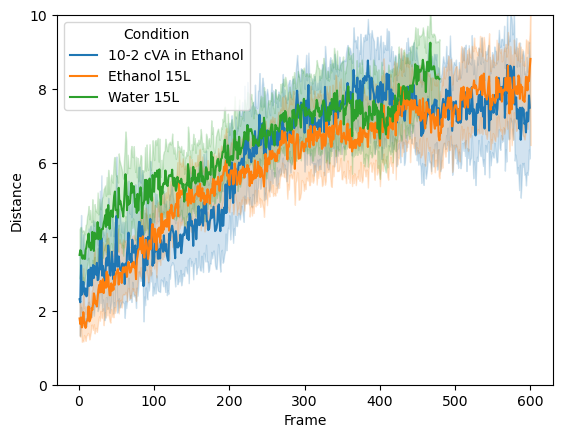

In [8]:
ax = sbs.lineplot(data = primary_df, x = 'Frame', y = 'Distance', hue = 'Condition')
plt.ylim(0,10)
plt.show()

In [9]:
def retention_value(df, column_name, constant):
    """
    Compare a column in a pandas DataFrame to a constant and assign values based on the comparison.

    Parameters:
        df (pandas.DataFrame): The DataFrame containing the column to compare.
        column_name (str): The name of the column to compare.
        constant (float): The constant to compare against.

    Returns:
        pandas.DataFrame: The original DataFrame with a new column 'Retention Value' containing the assigned values.
    """
    def compare_value(value):
        if value < constant:
            return 1
        return 0

    df['Retention Value'] = df[column_name].apply(compare_value)
    return df

primary_df = retention_value(primary_df, 'Distance', 3.5)

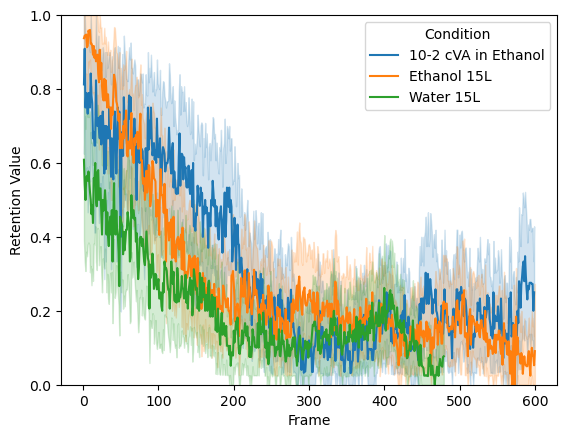

In [10]:
ax = sbs.lineplot(data = primary_df, x = 'Frame', y = 'Retention Value', hue = 'Condition')
plt.ylim(0,1)
plt.show()

In [11]:
primary_df = calculate_distance_from_centroid(primary_df)
# ax = sbs.lineplot(data = primary_df, x = 'Frame', y = 'Distance', hue = 'Condition')
# plt.ylim(0,15)
# plt.show()

13.212720000000001, 17.267819999999997
20.519320000000004, 6.488260000000001
10.41266, 14.09442
14.717179999999999, 16.805239999999998
16.075519999999997, 13.310820000000001
17.45552, 14.864019999999998
12.94894, 12.715799999999996
15.167279999999998, 12.96754
11.556160000000002, 15.4384
15.336980000000004, 17.1778
15.803219999999996, 13.603840000000002
16.82964, 16.2317


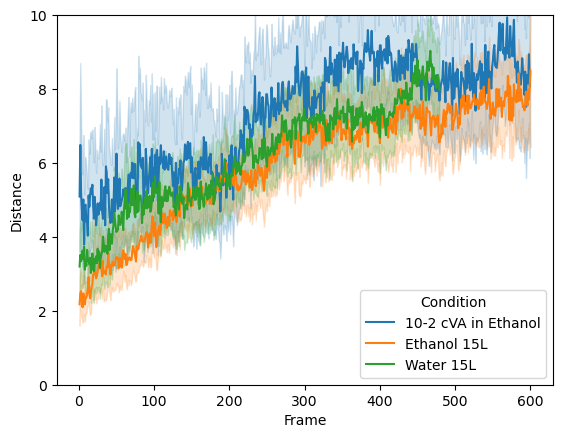

In [12]:
ax = sbs.lineplot(data = primary_df, x = 'Frame', y = 'Distance', hue = 'Condition')
plt.ylim(0,10)
plt.show()

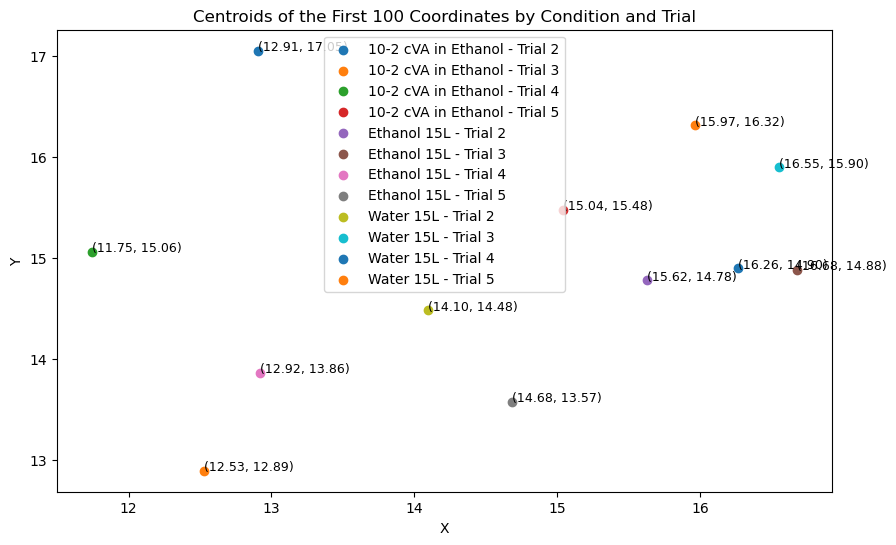

,Y,X,Speed,VY,Frame,Trial,Condition,Distance,Retention Value
17,16.986,12.807,0.544,0.341,77.0,Trial 2,10-2 cVA in Ethanol,0.120647,1
18,17.037,12.830,0.533,0.515,78.0,Trial 2,10-2 cVA in Ethanol,0.078971,1
23,17.136,13.085,0.615,0.285,83.0,Trial 2,10-2 cVA in Ethanol,0.196098,1
31,17.049,12.880,0.708,-0.427,91.0,Trial 2,10-2 cVA in Ethanol,0.027624,1
32,16.978,12.863,0.802,-0.712,92.0,Trial 2,10-2 cVA in Ethanol,0.087123,1
...,...,...,...,...,...,...,...,...,...
96782,27.148,19.388,0.781,0.279,473.0,Trial 5,Water 15L,11.359696,0
96783,27.184,19.290,1.250,0.362,474.0,Trial 5,Water 15L,11.364990,0
96784,27.227,19.188,0.943,0.428,475.0,Trial 5,Water 15L,11.376820,0
96785,27.255,19.107,0.846,0.279,476.0,Trial 5,Water 15L,11.381064,0


In [13]:
calculate_distance_from_centroid_with_plot(primary_df)